In [8]:
import pandas as pd
import numpy as np

CsvPath = "../logs/260305.csv"

DfRaw = pd.read_csv(CsvPath)

print("Shape:", DfRaw.shape)
print("\nColumns:")
print(DfRaw.columns.tolist())

print("\nDtypes:")
print(DfRaw.dtypes)

print("\nHead:")
display(DfRaw.head(5))

print("\nTail:")
display(DfRaw.tail(5))

Shape: (253144, 9)

Columns:
['id', 'symbol', 'timestamp', 'bid', 'ask', 'kal', 'mid', 'spread', 'k2']

Dtypes:
id             int64
symbol           str
timestamp        str
bid          float64
ask          float64
kal          float64
mid          float64
spread       float64
k2           float64
dtype: object

Head:


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
0,35884041,XAUUSD,2026-03-05 10:01:00.512+11,5150.07,5150.93,5142.12,5150.50,0.86,5141.15
1,35884042,XAUUSD,2026-03-05 10:01:00.741+11,5148.82,5149.66,5142.80,5149.24,0.84,5141.22
2,35884043,XAUUSD,2026-03-05 10:01:00.985+11,5149.51,5150.26,5143.48,5149.89,0.75,5141.32
3,35884044,XAUUSD,2026-03-05 10:01:01.224+11,5150.24,5150.98,5144.15,5150.61,0.74,5141.44
4,35884045,XAUUSD,2026-03-05 10:01:01.454+11,5149.73,5150.46,5144.72,5150.09,0.73,5141.58



Tail:


,id,symbol,timestamp,bid,ask,kal,mid,spread,k2
253139,36137180,XAUUSD,2026-03-06 08:58:58.92+11,5081.63,5082.00,5081.57,5081.82,0.37,5081.61
253140,36137181,XAUUSD,2026-03-06 08:58:59.213+11,5081.50,5081.86,5081.58,5081.68,0.36,5081.61
253141,36137182,XAUUSD,2026-03-06 08:58:59.442+11,5081.03,5081.40,5081.54,5081.22,0.37,5081.60
253142,36137183,XAUUSD,2026-03-06 08:58:59.665+11,5081.09,5081.48,5081.52,5081.28,0.39,5081.60
253143,36137184,XAUUSD,2026-03-06 08:58:59.895+11,5080.88,5081.30,5081.48,5081.09,0.42,5081.60


In [19]:
Df = DfRaw.copy()

TimestampText = Df["timestamp"].str.replace(r"(\+\d{2})$", r"\1:00", regex=True)

Df["timestamp"] = pd.to_datetime(
    TimestampText,
    format="mixed"
)

Df = Df.sort_values(["timestamp", "id"]).reset_index(drop=True)

Df["MidCalc"] = (Df["bid"] + Df["ask"]) / 2.0
Df["SpreadCalc"] = Df["ask"] - Df["bid"]

Df["MidDiff"] = Df["mid"] - Df["MidCalc"]
Df["SpreadDiff"] = Df["spread"] - Df["SpreadCalc"]

print("Parsed timestamp dtype:", Df["timestamp"].dtype)
print("Rows:", len(Df))

print("\nTimestamp range:")
print(Df["timestamp"].min(), "->", Df["timestamp"].max())

print("\nID monotonic increasing:", Df["id"].is_monotonic_increasing)
print("Timestamp monotonic increasing:", Df["timestamp"].is_monotonic_increasing)

print("\nDuplicate ids:", Df["id"].duplicated().sum())
print("Duplicate timestamps:", Df["timestamp"].duplicated().sum())

print("\nMax |mid - calc_mid|:", Df["MidDiff"].abs().max())
print("Max |spread - calc_spread|:", Df["SpreadDiff"].abs().max())

print("\nNull counts:")
print(Df.isnull().sum())

display(
    Df[[
        "id", "timestamp", "bid", "ask", "mid", "MidCalc",
        "spread", "SpreadCalc", "kal", "k2"
    ]].head(10)
)

Parsed timestamp dtype: datetime64[us, UTC+11:00]
Rows: 253144

Timestamp range:
2026-03-05 10:01:00.512000+11:00 -> 2026-03-06 08:58:59.895000+11:00

ID monotonic increasing: True
Timestamp monotonic increasing: True

Duplicate ids: 0
Duplicate timestamps: 0

Max |mid - calc_mid|: 0.005000000000109139
Max |spread - calc_spread|: 8.731348977164544e-13

Null counts:
id            0
symbol        0
timestamp     0
bid           0
ask           0
kal           0
mid           0
spread        0
k2            0
MidCalc       0
SpreadCalc    0
MidDiff       0
SpreadDiff    0
dtype: int64


,id,timestamp,bid,ask,mid,MidCalc,spread,SpreadCalc,kal,k2
0,35884041,2026-03-05 10:01:00.512000+11:00,5150.07,5150.93,5150.50,5150.500,0.86,0.86,5142.12,5141.15
1,35884042,2026-03-05 10:01:00.741000+11:00,5148.82,5149.66,5149.24,5149.240,0.84,0.84,5142.80,5141.22
2,35884043,2026-03-05 10:01:00.985000+11:00,5149.51,5150.26,5149.89,5149.885,0.75,0.75,5143.48,5141.32
3,35884044,2026-03-05 10:01:01.224000+11:00,5150.24,5150.98,5150.61,5150.610,0.74,0.74,5144.15,5141.44
4,35884045,2026-03-05 10:01:01.454000+11:00,5149.73,5150.46,5150.09,5150.095,0.73,0.73,5144.72,5141.58
5,35884046,2026-03-05 10:01:01.752000+11:00,5146.84,5147.64,5147.24,5147.240,0.80,0.80,5144.96,5141.73
6,35884047,2026-03-05 10:01:01.977000+11:00,5147.57,5148.45,5148.01,5148.010,0.88,0.88,5145.25,5141.89
7,35884048,2026-03-05 10:01:02.183000+11:00,5147.40,5148.32,5147.86,5147.860,0.92,0.92,5145.50,5142.04
8,35884049,2026-03-05 10:01:02.417000+11:00,5147.75,5148.66,5148.20,5148.205,0.91,0.91,5145.75,5142.21
9,35884050,2026-03-05 10:01:02.667000+11:00,5147.74,5148.66,5148.20,5148.200,0.92,0.92,5145.99,5142.37


In [22]:
Df["DeltaTimeSec"] = Df["timestamp"].diff().dt.total_seconds()

Df["DeltaMid"] = Df["mid"].diff()
Df["AbsDeltaMid"] = Df["DeltaMid"].abs()

print("DeltaTimeSec stats:")
print(Df["DeltaTimeSec"].describe())

print("\nDeltaMid stats:")
print(Df["DeltaMid"].describe())

print("\nAbsDeltaMid stats:")
print(Df["AbsDeltaMid"].describe())

print("\nTop 10 largest time gaps:")
display(Df.sort_values("DeltaTimeSec", ascending=False).head(10)[
    ["timestamp", "DeltaTimeSec", "mid"]
])

print("\nTop 10 largest single-tick price jumps:")
display(Df.sort_values("AbsDeltaMid", ascending=False).head(10)[
    ["timestamp", "DeltaMid", "mid"]
])

DeltaTimeSec stats:
count    253143.000000
mean          0.326611
std           0.268244
min           0.200000
25%           0.224000
50%           0.228000
75%           0.296000
max          14.824000
Name: DeltaTimeSec, dtype: float64

DeltaMid stats:
count    253143.000000
mean         -0.000274
std           0.213473
min         -13.080000
25%          -0.060000
50%           0.000000
75%           0.060000
max           3.830000
Name: DeltaMid, dtype: float64

AbsDeltaMid stats:
count    253143.000000
mean          0.123277
std           0.174280
min           0.000000
25%           0.020000
50%           0.060000
75%           0.180000
max          13.080000
Name: AbsDeltaMid, dtype: float64

Top 10 largest time gaps:


,timestamp,DeltaTimeSec,mid
145396,2026-03-06 00:43:13.269000+11:00,14.824,5132.50
147762,2026-03-06 00:54:37.026000+11:00,13.974,5126.04
12677,2026-03-05 11:41:59.236000+11:00,8.491,5173.86
250791,2026-03-06 08:40:54.858000+11:00,8.454,5075.08
248997,2026-03-06 08:25:13.659000+11:00,7.559,5080.16
55160,2026-03-05 15:59:12.574000+11:00,7.062,5170.72
11556,2026-03-05 11:31:48.587000+11:00,6.867,5170.94
3096,2026-03-05 10:24:29.299000+11:00,6.863,5154.41
50585,2026-03-05 15:23:27.465000+11:00,6.120,5184.07
125899,2026-03-05 22:46:52.904000+11:00,6.050,5160.64



Top 10 largest single-tick price jumps:


,timestamp,DeltaMid,mid
139353,2026-03-06 00:16:57.738000+11:00,-13.08,5139.62
140720,2026-03-06 00:22:29.462000+11:00,-7.22,5097.59
165055,2026-03-06 02:08:39.479000+11:00,-6.68,5079.52
165165,2026-03-06 02:09:06.328000+11:00,-5.71,5062.02
140643,2026-03-06 00:22:11.170000+11:00,-5.62,5106.99
106746,2026-03-05 20:39:57.264000+11:00,-5.47,5154.38
165075,2026-03-06 02:08:44.210000+11:00,-5.14,5075.25
140920,2026-03-06 00:23:16.854000+11:00,-4.69,5084.70
67231,2026-03-05 17:10:42.956000+11:00,-4.51,5127.71
139589,2026-03-06 00:17:55.435000+11:00,-4.45,5132.62


In [23]:
WindowSec = 120

FutureTime = Df["timestamp"] + pd.Timedelta(seconds=WindowSec)

# For each row, estimate how many future rows are within 120s
# We'll approximate using searchsorted

Timestamps = Df["timestamp"].values

Counts = []

for i in range(0, len(Df), 10000):  # sample every 10k rows
    t_end = Timestamps[i] + np.timedelta64(WindowSec, 's')
    j = np.searchsorted(Timestamps, t_end)
    Counts.append(j - i)

print("Approx ticks inside 120s window (sampled):")
print("Mean:", np.mean(Counts))
print("Min:", np.min(Counts))
print("Max:", np.max(Counts))

Approx ticks inside 120s window (sampled):
Mean: 397.7307692307692
Min: 226
Max: 501


In [24]:
WindowSec = 120
TargetDist = 1.0

Timestamps = Df["timestamp"].values
MidValues = Df["mid"].to_numpy()

UpFirst = np.full(len(Df), False, dtype=bool)
DownFirst = np.full(len(Df), False, dtype=bool)
Timeout = np.full(len(Df), False, dtype=bool)

TimeToUpSec = np.full(len(Df), np.nan, dtype=float)
TimeToDownSec = np.full(len(Df), np.nan, dtype=float)
TimeToFirstHitSec = np.full(len(Df), np.nan, dtype=float)

WinningSide = np.full(len(Df), "", dtype=object)

for i in range(len(Df)):
    EntryMid = MidValues[i]
    UpBarrier = EntryMid + TargetDist
    DownBarrier = EntryMid - TargetDist
    EndTime = Timestamps[i] + np.timedelta64(WindowSec, "s")

    j_end = np.searchsorted(Timestamps, EndTime, side="right")
    FutureMid = MidValues[i + 1:j_end]
    FutureTime = Timestamps[i + 1:j_end]

    if len(FutureMid) == 0:
        Timeout[i] = True
        WinningSide[i] = "TIMEOUT"
        continue

    UpHits = np.where(FutureMid >= UpBarrier)[0]
    DownHits = np.where(FutureMid <= DownBarrier)[0]

    FirstUpIdx = UpHits[0] if len(UpHits) > 0 else None
    FirstDownIdx = DownHits[0] if len(DownHits) > 0 else None

    if FirstUpIdx is not None:
        TimeToUpSec[i] = (FutureTime[FirstUpIdx] - Timestamps[i]) / np.timedelta64(1, "s")

    if FirstDownIdx is not None:
        TimeToDownSec[i] = (FutureTime[FirstDownIdx] - Timestamps[i]) / np.timedelta64(1, "s")

    if (FirstUpIdx is None) and (FirstDownIdx is None):
        Timeout[i] = True
        WinningSide[i] = "TIMEOUT"
    elif FirstDownIdx is None or (FirstUpIdx is not None and FirstUpIdx < FirstDownIdx):
        UpFirst[i] = True
        WinningSide[i] = "UP"
        TimeToFirstHitSec[i] = TimeToUpSec[i]
    else:
        DownFirst[i] = True
        WinningSide[i] = "DOWN"
        TimeToFirstHitSec[i] = TimeToDownSec[i]

Df["UpFirst_1"] = UpFirst
Df["DownFirst_1"] = DownFirst
Df["Timeout_1"] = Timeout
Df["TimeToUpSec_1"] = TimeToUpSec
Df["TimeToDownSec_1"] = TimeToDownSec
Df["TimeToFirstHitSec_1"] = TimeToFirstHitSec
Df["WinningSide_1"] = WinningSide

print(Df["WinningSide_1"].value_counts(dropna=False))
print()
print(Df["TimeToFirstHitSec_1"].describe())

display(
    Df[[
        "id", "timestamp", "mid",
        "UpFirst_1", "DownFirst_1", "Timeout_1",
        "TimeToUpSec_1", "TimeToDownSec_1",
        "TimeToFirstHitSec_1", "WinningSide_1"
    ]].head(15)
)

WinningSide_1
DOWN       126091
UP         124200
TIMEOUT      2853
Name: count, dtype: int64

count    250291.000000
mean         17.285537
std          19.484626
min           0.200000
25%           4.430000
50%          10.191000
75%          22.464500
max         119.947000
Name: TimeToFirstHitSec_1, dtype: float64


,id,timestamp,mid,UpFirst_1,DownFirst_1,Timeout_1,TimeToUpSec_1,TimeToDownSec_1,TimeToFirstHitSec_1,WinningSide_1
0,35884041,2026-03-05 10:01:00.512000+11:00,5150.50,False,True,False,72.606,0.229,0.229,DOWN
1,35884042,2026-03-05 10:01:00.741000+11:00,5149.24,True,False,False,0.483,1.011,0.483,UP
2,35884043,2026-03-05 10:01:00.985000+11:00,5149.89,False,True,False,69.291,0.767,0.767,DOWN
3,35884044,2026-03-05 10:01:01.224000+11:00,5150.61,False,True,False,71.894,0.528,0.528,DOWN
4,35884045,2026-03-05 10:01:01.454000+11:00,5150.09,False,True,False,71.216,0.298,0.298,DOWN
5,35884046,2026-03-05 10:01:01.752000+11:00,5147.24,True,False,False,1.421,NaN,1.421,UP
6,35884047,2026-03-05 10:01:01.977000+11:00,5148.01,True,False,False,2.791,NaN,2.791,UP
7,35884048,2026-03-05 10:01:02.183000+11:00,5147.86,True,False,False,2.585,NaN,2.585,UP
8,35884049,2026-03-05 10:01:02.417000+11:00,5148.20,True,False,False,2.351,NaN,2.351,UP
9,35884050,2026-03-05 10:01:02.667000+11:00,5148.20,True,False,False,2.101,NaN,2.101,UP


In [25]:
PathNetMove = np.full(len(Df), np.nan, dtype=float)
PathGrossMove = np.full(len(Df), np.nan, dtype=float)
PathEfficiency = np.full(len(Df), np.nan, dtype=float)
PathWorstAdverse = np.full(len(Df), np.nan, dtype=float)
PathNumTicks = np.full(len(Df), np.nan, dtype=float)

for i in range(len(Df)):
    Side = Df.at[i, "WinningSide_1"]
    
    if Side == "TIMEOUT":
        continue

    HitSec = Df.at[i, "TimeToFirstHitSec_1"]
    EndTime = Timestamps[i] + np.timedelta64(int(round(HitSec * 1000)), "ms")
    j_end = np.searchsorted(Timestamps, EndTime, side="right")

    PathMid = MidValues[i:j_end]

    if len(PathMid) < 2:
        continue

    Steps = np.diff(PathMid)
    GrossMove = np.abs(Steps).sum()

    if Side == "UP":
        NetMove = PathMid[-1] - PathMid[0]
        AdverseSeries = PathMid - PathMid[0]
        WorstAdverse = AdverseSeries.min()
    else:
        NetMove = PathMid[0] - PathMid[-1]
        AdverseSeries = PathMid[0] - PathMid
        WorstAdverse = AdverseSeries.min()

    Efficiency = NetMove / GrossMove if GrossMove > 0 else np.nan

    PathNetMove[i] = NetMove
    PathGrossMove[i] = GrossMove
    PathEfficiency[i] = Efficiency
    PathWorstAdverse[i] = WorstAdverse
    PathNumTicks[i] = len(PathMid)

Df["PathNetMove_1"] = PathNetMove
Df["PathGrossMove_1"] = PathGrossMove
Df["PathEfficiency_1"] = PathEfficiency
Df["PathWorstAdverse_1"] = PathWorstAdverse
Df["PathNumTicks_1"] = PathNumTicks

print("PathEfficiency stats:")
print(Df["PathEfficiency_1"].describe())

print("\nPathWorstAdverse stats:")
print(Df["PathWorstAdverse_1"].describe())

print("\nPathNumTicks stats:")
print(Df["PathNumTicks_1"].describe())

display(
    Df[[
        "id", "timestamp", "mid", "WinningSide_1", "TimeToFirstHitSec_1",
        "PathNetMove_1", "PathGrossMove_1", "PathEfficiency_1",
        "PathWorstAdverse_1", "PathNumTicks_1"
    ]].head(15)
)

PathEfficiency stats:
count    250291.000000
mean          0.388136
std           0.268961
min           0.025456
25%           0.170306
50%           0.308642
75%           0.550847
max           1.000000
Name: PathEfficiency_1, dtype: float64

PathWorstAdverse stats:
count    250291.000000
mean         -0.306207
std           0.295406
min          -0.990000
25%          -0.520000
50%          -0.240000
75%          -0.020000
max           0.000000
Name: PathWorstAdverse_1, dtype: float64

PathNumTicks stats:
count    250291.000000
mean         49.043881
std          46.385762
min           2.000000
25%          17.000000
50%          34.000000
75%          66.000000
max         455.000000
Name: PathNumTicks_1, dtype: float64


,id,timestamp,mid,WinningSide_1,TimeToFirstHitSec_1,PathNetMove_1,PathGrossMove_1,PathEfficiency_1,PathWorstAdverse_1,PathNumTicks_1
0,35884041,2026-03-05 10:01:00.512000+11:00,5150.50,DOWN,0.229,1.26,1.26,1.000000,0.00,2.0
1,35884042,2026-03-05 10:01:00.741000+11:00,5149.24,UP,0.483,1.37,1.37,1.000000,0.00,3.0
2,35884043,2026-03-05 10:01:00.985000+11:00,5149.89,DOWN,0.767,2.65,4.09,0.647922,-0.72,4.0
3,35884044,2026-03-05 10:01:01.224000+11:00,5150.61,DOWN,0.528,3.37,3.37,1.000000,0.00,3.0
4,35884045,2026-03-05 10:01:01.454000+11:00,5150.09,DOWN,0.298,2.85,2.85,1.000000,0.00,2.0
5,35884046,2026-03-05 10:01:01.752000+11:00,5147.24,UP,1.421,1.19,2.25,0.528889,0.00,7.0
6,35884047,2026-03-05 10:01:01.977000+11:00,5148.01,UP,2.791,1.26,2.78,0.453237,-0.19,12.0
7,35884048,2026-03-05 10:01:02.183000+11:00,5147.86,UP,2.585,1.41,2.63,0.536122,-0.04,11.0
8,35884049,2026-03-05 10:01:02.417000+11:00,5148.20,UP,2.351,1.07,2.29,0.467249,-0.38,10.0
9,35884050,2026-03-05 10:01:02.667000+11:00,5148.20,UP,2.101,1.07,2.29,0.467249,-0.38,9.0


In [26]:
EfficiencyThreshold = 0.65
AdverseThreshold = -0.30
MaxTimeThreshold = 25.0

CleanLabel = []

for i in range(len(Df)):
    Side = Df.at[i, "WinningSide_1"]

    if Side == "TIMEOUT":
        CleanLabel.append("TIMEOUT")
        continue

    Eff = Df.at[i, "PathEfficiency_1"]
    Adv = Df.at[i, "PathWorstAdverse_1"]
    T = Df.at[i, "TimeToFirstHitSec_1"]

    if (Eff >= EfficiencyThreshold) and (Adv >= AdverseThreshold) and (T <= MaxTimeThreshold):
        if Side == "UP":
            CleanLabel.append("CLEAN_UP")
        else:
            CleanLabel.append("CLEAN_DOWN")
    else:
        if Side == "UP":
            CleanLabel.append("MESSY_UP")
        else:
            CleanLabel.append("MESSY_DOWN")

Df["MoveQuality_1"] = CleanLabel

print(Df["MoveQuality_1"].value_counts())

MoveQuality_1
MESSY_DOWN    103106
MESSY_UP      100889
CLEAN_UP       23311
CLEAN_DOWN     22985
TIMEOUT         2853
Name: count, dtype: int64


In [27]:
Target = np.zeros(len(Df), dtype=int)

Target[Df["MoveQuality_1"] == "CLEAN_UP"] = 1
Target[Df["MoveQuality_1"] == "CLEAN_DOWN"] = -1

Df["TargetCleanDir_1"] = Target

print("Target distribution:")
print(pd.Series(Target).value_counts())

Target distribution:
 0    206848
 1     23311
-1     22985
Name: count, dtype: int64


In [28]:
FeatureCols = [
    "Ret20", "Ret50", "Ret100",
    "Vol20", "Vol50", "Vol100",
    "Range20", "Range50",
    "Slope20", "TickRate20",
    "DistFromMean20"
]

CleanMask = Df["IsCleanMove_1"] == 1
NoiseMask = Df["IsCleanMove_1"] == 0

Comparison = pd.DataFrame({
    "CleanMean": Df.loc[CleanMask, FeatureCols].mean(),
    "NoiseMean": Df.loc[NoiseMask, FeatureCols].mean()
})

display(Comparison)

KeyError: 'IsCleanMove_1'

In [29]:
Df["IsCleanMove_1"] = (Df["TargetCleanDir_1"] != 0).astype(int)

print(Df["IsCleanMove_1"].value_counts())

IsCleanMove_1
0    206848
1     46296
Name: count, dtype: int64


In [30]:
FeatureCols = [
    "Ret20", "Ret50", "Ret100",
    "Vol20", "Vol50", "Vol100",
    "Range20", "Range50",
    "Slope20", "TickRate20",
    "DistFromMean20"
]

CleanMask = Df["IsCleanMove_1"] == 1
NoiseMask = Df["IsCleanMove_1"] == 0

Comparison = pd.DataFrame({
    "CleanMean": Df.loc[CleanMask, FeatureCols].mean(),
    "NoiseMean": Df.loc[NoiseMask, FeatureCols].mean()
})

display(Comparison)

KeyError: "None of [Index(['Ret20', 'Ret50', 'Ret100', 'Vol20', 'Vol50', 'Vol100', 'Range20',\n       'Range50', 'Slope20', 'TickRate20', 'DistFromMean20'],\n      dtype='str')] are in the [columns]"

In [31]:
FeatureCols = [
    "Ret20", "Ret50", "Ret100",
    "Vol20", "Vol50", "Vol100",
    "Range20", "Range50",
    "Slope20", "TickRate20",
    "DistFromMean20"
]

MissingCols = [c for c in FeatureCols if c not in Df.columns]

print("Missing feature columns:")
print(MissingCols)

Missing feature columns:
['Ret20', 'Ret50', 'Ret100', 'Vol20', 'Vol50', 'Vol100', 'Range20', 'Range50', 'Slope20', 'TickRate20', 'DistFromMean20']


In [32]:
def rolling_slope(series, window):
    slopes = np.full(len(series), np.nan)
    for i in range(window, len(series)):
        y = series[i-window:i]
        x = np.arange(window)
        coeffs = np.polyfit(x, y, 1)
        slopes[i] = coeffs[0]
    return slopes

Df["Ret20"] = Df["mid"].diff(20)
Df["Ret50"] = Df["mid"].diff(50)
Df["Ret100"] = Df["mid"].diff(100)

Df["Vol20"] = Df["mid"].rolling(20).std()
Df["Vol50"] = Df["mid"].rolling(50).std()
Df["Vol100"] = Df["mid"].rolling(100).std()

Df["Range20"] = Df["mid"].rolling(20).max() - Df["mid"].rolling(20).min()
Df["Range50"] = Df["mid"].rolling(50).max() - Df["mid"].rolling(50).min()

Df["Slope20"] = rolling_slope(Df["mid"].to_numpy(), 20)

Df["TickRate20"] = 20 / (
    (Df["timestamp"] - Df["timestamp"].shift(20)).dt.total_seconds()
)

Df["DistFromMean20"] = Df["mid"] - Df["mid"].rolling(20).mean()

print("Created feature columns:")
print([c for c in FeatureCols if c in Df.columns])

display(
    Df[[
        "mid", "Ret20", "Ret50", "Ret100",
        "Vol20", "Vol50", "Vol100",
        "Range20", "Range50",
        "Slope20", "TickRate20", "DistFromMean20"
    ]].tail(10)
)

Created feature columns:
['Ret20', 'Ret50', 'Ret100', 'Vol20', 'Vol50', 'Vol100', 'Range20', 'Range50', 'Slope20', 'TickRate20', 'DistFromMean20']


,mid,Ret20,Ret50,Ret100,Vol20,Vol50,Vol100,Range20,Range50,Slope20,TickRate20,DistFromMean20
253134,5081.16,-0.26,-0.83,-1.19,0.109592,0.318452,0.474671,0.42,0.93,-0.004992,3.701647,-0.2700
253135,5081.40,-0.03,-0.62,-0.70,0.109798,0.318174,0.470983,0.42,0.93,-0.009398,3.628447,-0.0285
253136,5081.91,0.45,0.08,-0.20,0.153859,0.319057,0.468786,0.75,0.93,-0.009827,3.639672,0.4590
253137,5081.83,0.40,0.00,-0.45,0.175466,0.319057,0.463331,0.75,0.93,-0.002451,3.635042,0.3590
253138,5081.82,0.39,-0.25,-0.51,0.191599,0.315049,0.456789,0.75,0.93,0.002632,3.636364,0.3295
253139,5081.82,0.35,-0.23,-0.75,0.205134,0.311393,0.444851,0.75,0.93,0.006970,3.685957,0.3120
253140,5081.68,0.23,-0.37,-0.65,0.208136,0.307000,0.436997,0.75,0.93,0.011353,3.639672,0.1605
253141,5081.22,-0.23,-0.85,-0.49,0.218285,0.308573,0.437074,0.75,0.93,0.012895,3.642324,-0.2880
253142,5081.28,-0.17,-0.81,0.15,0.223900,0.307031,0.436154,0.75,0.93,0.007519,3.638348,-0.2195
253143,5081.09,-0.38,-0.98,0.21,0.241932,0.310812,0.433779,0.82,1.00,0.003346,3.768607,-0.3905


In [33]:
FeatureCols = [
    "Ret20", "Ret50", "Ret100",
    "Vol20", "Vol50", "Vol100",
    "Range20", "Range50",
    "Slope20", "TickRate20",
    "DistFromMean20"
]

CleanMask = Df["IsCleanMove_1"] == 1
NoiseMask = Df["IsCleanMove_1"] == 0

Comparison = pd.DataFrame({
    "CleanMean": Df.loc[CleanMask, FeatureCols].mean(),
    "NoiseMean": Df.loc[NoiseMask, FeatureCols].mean()
})

display(Comparison)

,CleanMean,NoiseMean
Ret20,-0.035724,0.001487
Ret50,-0.097646,0.005544
Ret100,-0.166411,0.004694
Vol20,0.392778,0.310067
Vol50,0.627846,0.488110
Vol100,0.881064,0.686490
Range20,1.262727,0.998172
Range50,2.235359,1.750162
Slope20,-0.001739,0.000065
TickRate20,3.560732,3.251181


In [34]:
DirFeatureCols = [
    "Ret20", "Ret50", "Ret100",
    "Vol20", "Vol50", "Vol100",
    "Range20", "Range50",
    "Slope20", "TickRate20",
    "DistFromMean20"
]

UpMask = Df["TargetCleanDir_1"] == 1
DownMask = Df["TargetCleanDir_1"] == -1

DirComparison = pd.DataFrame({
    "CleanUpMean": Df.loc[UpMask, DirFeatureCols].mean(),
    "CleanDownMean": Df.loc[DownMask, DirFeatureCols].mean()
})

display(DirComparison)

,CleanUpMean,CleanDownMean
Ret20,-0.037540,-0.033882
Ret50,-0.125891,-0.069001
Ret100,-0.261039,-0.070424
Vol20,0.394026,0.391513
Vol50,0.626684,0.629026
Vol100,0.890564,0.871427
Range20,1.267476,1.257910
Range50,2.237032,2.233663
Slope20,-0.002416,-0.001052
TickRate20,3.564102,3.557315


In [35]:
Df["PreSlope5"] = Df["mid"].diff(5)
Df["PreSlope10"] = Df["mid"].diff(10)

UpMask = Df["TargetCleanDir_1"] == 1
DownMask = Df["TargetCleanDir_1"] == -1

ShortTermComparison = pd.DataFrame({
    "CleanUpMean": Df.loc[UpMask, ["PreSlope5", "PreSlope10"]].mean(),
    "CleanDownMean": Df.loc[DownMask, ["PreSlope5", "PreSlope10"]].mean()
})

display(ShortTermComparison)

,CleanUpMean,CleanDownMean
PreSlope5,-0.002156,-0.017284
PreSlope10,-0.027318,-0.004929


In [36]:
DistCompare = pd.DataFrame({
    "Up_q10": Df.loc[UpMask, "PreSlope5"].quantile(0.10),
    "Up_q25": Df.loc[UpMask, "PreSlope5"].quantile(0.25),
    "Up_q50": Df.loc[UpMask, "PreSlope5"].quantile(0.50),
    "Up_q75": Df.loc[UpMask, "PreSlope5"].quantile(0.75),
    "Up_q90": Df.loc[UpMask, "PreSlope5"].quantile(0.90),

    "Down_q10": Df.loc[DownMask, "PreSlope5"].quantile(0.10),
    "Down_q25": Df.loc[DownMask, "PreSlope5"].quantile(0.25),
    "Down_q50": Df.loc[DownMask, "PreSlope5"].quantile(0.50),
    "Down_q75": Df.loc[DownMask, "PreSlope5"].quantile(0.75),
    "Down_q90": Df.loc[DownMask, "PreSlope5"].quantile(0.90),
}, index=["PreSlope5"]).T

display(DistCompare)

,PreSlope5
Up_q10,-0.57
Up_q25,-0.26
Up_q50,0.00
Up_q75,0.26
Up_q90,0.61
Down_q10,-0.62
Down_q25,-0.26
Down_q50,0.00
Down_q75,0.24
Down_q90,0.58


In [37]:
DistCompare10 = pd.DataFrame({
    "Up_q10": Df.loc[UpMask, "PreSlope10"].quantile(0.10),
    "Up_q25": Df.loc[UpMask, "PreSlope10"].quantile(0.25),
    "Up_q50": Df.loc[UpMask, "PreSlope10"].quantile(0.50),
    "Up_q75": Df.loc[UpMask, "PreSlope10"].quantile(0.75),
    "Up_q90": Df.loc[UpMask, "PreSlope10"].quantile(0.90),

    "Down_q10": Df.loc[DownMask, "PreSlope10"].quantile(0.10),
    "Down_q25": Df.loc[DownMask, "PreSlope10"].quantile(0.25),
    "Down_q50": Df.loc[DownMask, "PreSlope10"].quantile(0.50),
    "Down_q75": Df.loc[DownMask, "PreSlope10"].quantile(0.75),
    "Down_q90": Df.loc[DownMask, "PreSlope10"].quantile(0.90),
}, index=["PreSlope10"]).T

display(DistCompare10)

,PreSlope10
Up_q10,-0.900
Up_q25,-0.410
Up_q50,-0.010
Up_q75,0.390
Up_q90,0.891
Down_q10,-0.900
Down_q25,-0.410
Down_q50,0.005
Down_q75,0.390
Down_q90,0.920


In [38]:
Df["RecentHigh10"] = Df["mid"].rolling(10).max()
Df["RecentLow10"] = Df["mid"].rolling(10).min()

Df["RecentHigh20"] = Df["mid"].rolling(20).max()
Df["RecentLow20"] = Df["mid"].rolling(20).min()

Df["PullbackFromHigh10"] = Df["mid"] - Df["RecentHigh10"]
Df["BounceFromLow10"] = Df["mid"] - Df["RecentLow10"]

Df["VolExpansion20"] = Df["Vol20"] - Df["Vol20"].shift(20)
Df["RangeExpansion20"] = Df["Range20"] - Df["Range20"].shift(20)

display(
    Df[[
        "mid",
        "RecentHigh10", "RecentLow10",
        "RecentHigh20", "RecentLow20",
        "PullbackFromHigh10", "BounceFromLow10",
        "Vol20", "VolExpansion20",
        "Range20", "RangeExpansion20"
    ]].tail(15)
)

,mid,RecentHigh10,RecentLow10,RecentHigh20,RecentLow20,PullbackFromHigh10,BounceFromLow10,Vol20,VolExpansion20,Range20,RangeExpansion20
253129,5081.45,5081.58,5081.45,5081.58,5081.19,-0.13,0.00,0.099730,0.004579,0.39,-0.01
253130,5081.38,5081.58,5081.38,5081.58,5081.19,-0.20,0.00,0.100518,-0.052186,0.39,-0.22
253131,5081.27,5081.58,5081.27,5081.58,5081.20,-0.31,0.00,0.091091,-0.142338,0.38,-0.52
253132,5081.27,5081.58,5081.27,5081.58,5081.27,-0.31,0.00,0.082014,-0.201646,0.31,-0.59
253133,5081.29,5081.58,5081.27,5081.58,5081.27,-0.29,0.02,0.089449,-0.209701,0.31,-0.59
253134,5081.16,5081.58,5081.16,5081.58,5081.16,-0.42,0.00,0.109592,-0.201913,0.42,-0.48
253135,5081.40,5081.57,5081.16,5081.58,5081.16,-0.17,0.24,0.109798,-0.208274,0.42,-0.48
253136,5081.91,5081.91,5081.16,5081.91,5081.16,0.00,0.75,0.153859,-0.165487,0.75,-0.14
253137,5081.83,5081.91,5081.16,5081.91,5081.16,-0.08,0.67,0.175466,-0.143906,0.75,-0.14
253138,5081.82,5081.91,5081.16,5081.91,5081.16,-0.09,0.66,0.191599,-0.124913,0.75,-0.14


In [39]:
Df["UpImpulse"] = (Df["Ret20"] > 0.3) & (Df["Slope20"] > 0)

Df["UpControlledPullback"] = (
    (Df["PullbackFromHigh10"] < 0) &
    (Df["PullbackFromHigh10"] > -0.4)
)

Df["UpBounce"] = (
    (Df["BounceFromLow10"] > 0.2) &
    ((Df["RecentHigh10"] - Df["mid"]) < 0.15)
)

Df["UpConfirmCandidate"] = (
    Df["UpImpulse"] &
    Df["UpControlledPullback"] &
    Df["UpBounce"]
)

print("Total UpConfirmCandidate:", Df["UpConfirmCandidate"].sum())

Total UpConfirmCandidate: 20172


In [40]:
UpMask = Df["UpConfirmCandidate"]

Results = Df.loc[UpMask, "TargetCleanDir_1"].value_counts()

print("Outcome distribution for UpConfirmCandidate:")
print(Results)

print("\nProbabilities:")
print(Results / Results.sum())

Outcome distribution for UpConfirmCandidate:
TargetCleanDir_1
 0    16384
-1     2042
 1     1746
Name: count, dtype: int64

Probabilities:
TargetCleanDir_1
 0    0.812215
-1    0.101229
 1    0.086556
Name: count, dtype: float64


In [41]:
SwingWindow = 10

Df["RollMaxCenter"] = Df["mid"].rolling(window=SwingWindow * 2 + 1, center=True).max()
Df["RollMinCenter"] = Df["mid"].rolling(window=SwingWindow * 2 + 1, center=True).min()

Df["SwingHighCandidate"] = Df["mid"] == Df["RollMaxCenter"]
Df["SwingLowCandidate"] = Df["mid"] == Df["RollMinCenter"]

print("SwingHighCandidate:", Df["SwingHighCandidate"].sum())
print("SwingLowCandidate:", Df["SwingLowCandidate"].sum())

display(
    Df.loc[
        Df["SwingHighCandidate"] | Df["SwingLowCandidate"],
        ["timestamp", "mid", "SwingHighCandidate", "SwingLowCandidate"]
    ].head(30)
)

SwingHighCandidate: 9583
SwingLowCandidate: 9523


,timestamp,mid,SwingHighCandidate,SwingLowCandidate
20,2026-03-05 10:01:05.446000+11:00,5147.82,False,True
24,2026-03-05 10:01:06.331000+11:00,5149.52,True,False
42,2026-03-05 10:01:11.924000+11:00,5149.22,False,True
49,2026-03-05 10:01:14.350000+11:00,5150.23,True,False
51,2026-03-05 10:01:14.842000+11:00,5150.23,True,False
57,2026-03-05 10:01:16.279000+11:00,5147.52,False,True
58,2026-03-05 10:01:16.503000+11:00,5147.52,False,True
82,2026-03-05 10:01:22.828000+11:00,5148.48,True,False
85,2026-03-05 10:01:23.745000+11:00,5148.48,True,False
96,2026-03-05 10:01:26.666000+11:00,5148.16,False,True


In [42]:
MinSwingMove = 0.8  # adjust later

Swings = Df.loc[
    Df["SwingHighCandidate"] | Df["SwingLowCandidate"],
    ["timestamp", "mid", "SwingHighCandidate", "SwingLowCandidate"]
].copy()

Swings["Type"] = None
Swings.loc[Swings["SwingHighCandidate"], "Type"] = "H"
Swings.loc[Swings["SwingLowCandidate"], "Type"] = "L"

Swings = Swings.sort_index()

Filtered = []
LastType = None
LastPrice = None

for idx, row in Swings.iterrows():
    CurrentType = row["Type"]
    CurrentPrice = row["mid"]

    if LastType is None:
        Filtered.append((idx, CurrentType, CurrentPrice))
        LastType = CurrentType
        LastPrice = CurrentPrice
        continue

    # If same type, keep more extreme one
    if CurrentType == LastType:
        if CurrentType == "H" and CurrentPrice > LastPrice:
            Filtered[-1] = (idx, CurrentType, CurrentPrice)
            LastPrice = CurrentPrice
        elif CurrentType == "L" and CurrentPrice < LastPrice:
            Filtered[-1] = (idx, CurrentType, CurrentPrice)
            LastPrice = CurrentPrice
        continue

    # If opposite type, enforce minimum move
    if abs(CurrentPrice - LastPrice) >= MinSwingMove:
        Filtered.append((idx, CurrentType, CurrentPrice))
        LastType = CurrentType
        LastPrice = CurrentPrice

PivotDf = pd.DataFrame(Filtered, columns=["Index", "Type", "Price"])
PivotDf = PivotDf.set_index("Index")

print("Final structural pivots:", len(PivotDf))
display(PivotDf.head(20))

Final structural pivots: 6531


,Type,Price
Index,,
20,L,5147.82
49,H,5150.23
57,L,5147.52
142,H,5150.24
154,L,5147.22
222,H,5153.04
229,L,5150.80
282,H,5152.98
292,L,5152.07


In [43]:
Legs = PivotDf.copy().reset_index()
Legs = Legs.rename(columns={"Index": "PivotIndex", "Type": "PivotType", "Price": "PivotPrice"})

Legs["NextPivotIndex"] = Legs["PivotIndex"].shift(-1)
Legs["NextPivotType"] = Legs["PivotType"].shift(-1)
Legs["NextPivotPrice"] = Legs["PivotPrice"].shift(-1)

Legs["StartTime"] = Df.loc[Legs["PivotIndex"], "timestamp"].values
Legs["EndTime"] = Df.loc[Legs["NextPivotIndex"].dropna().astype(int), "timestamp"].values.tolist() + [pd.NaT]

Legs["Direction"] = np.where(
    Legs["PivotType"] == "L",
    "UP",
    "DOWN"
)

Legs["Distance"] = np.where(
    Legs["Direction"] == "UP",
    Legs["NextPivotPrice"] - Legs["PivotPrice"],
    Legs["PivotPrice"] - Legs["NextPivotPrice"]
)

Legs["DurationSec"] = (Legs["EndTime"] - Legs["StartTime"]).dt.total_seconds()
Legs["Speed"] = Legs["Distance"] / Legs["DurationSec"]

Legs = Legs.dropna(subset=["NextPivotIndex"]).copy()

display(Legs.head(15))
print("Total legs:", len(Legs))

,PivotIndex,PivotType,PivotPrice,NextPivotIndex,NextPivotType,NextPivotPrice,StartTime,EndTime,Direction,Distance,DurationSec,Speed
0,20,L,5147.82,49.0,H,5150.23,2026-03-04 23:01:05.446,2026-03-04 23:01:14.350,UP,2.41,8.904,0.270665
1,49,H,5150.23,57.0,L,5147.52,2026-03-04 23:01:14.350,2026-03-04 23:01:16.279,DOWN,2.71,1.929,1.404873
2,57,L,5147.52,142.0,H,5150.24,2026-03-04 23:01:16.279,2026-03-04 23:01:49.166,UP,2.72,32.887,0.082707
3,142,H,5150.24,154.0,L,5147.22,2026-03-04 23:01:49.166,2026-03-04 23:01:52.804,DOWN,3.02,3.638,0.830126
4,154,L,5147.22,222.0,H,5153.04,2026-03-04 23:01:52.804,2026-03-04 23:02:16.233,UP,5.82,23.429,0.248410
5,222,H,5153.04,229.0,L,5150.80,2026-03-04 23:02:16.233,2026-03-04 23:02:17.811,DOWN,2.24,1.578,1.419518
6,229,L,5150.80,282.0,H,5152.98,2026-03-04 23:02:17.811,2026-03-04 23:02:32.544,UP,2.18,14.733,0.147967
7,282,H,5152.98,292.0,L,5152.07,2026-03-04 23:02:32.544,2026-03-04 23:02:36.284,DOWN,0.91,3.740,0.243316
8,292,L,5152.07,335.0,H,5153.83,2026-03-04 23:02:36.284,2026-03-04 23:02:52.110,UP,1.76,15.826,0.111209
9,335,H,5153.83,384.0,L,5151.62,2026-03-04 23:02:52.110,2026-03-04 23:03:10.243,DOWN,2.21,18.133,0.121877


Total legs: 6530


In [44]:
MinLegDistance = 1.0
MinLegSpeed = 0.02   # dollars per second; can tune later

Legs["IsBigLeg"] = (
    (Legs["Distance"] >= MinLegDistance) &
    (Legs["Speed"] >= MinLegSpeed)
)

print(Legs["IsBigLeg"].value_counts())

display(
    Legs.loc[Legs["IsBigLeg"], [
        "PivotIndex", "PivotType", "PivotPrice",
        "NextPivotIndex", "NextPivotType", "NextPivotPrice",
        "Direction", "Distance", "DurationSec", "Speed"
    ]].head(20)
)

IsBigLeg
True     5665
False     865
Name: count, dtype: int64


,PivotIndex,PivotType,PivotPrice,NextPivotIndex,NextPivotType,NextPivotPrice,Direction,Distance,DurationSec,Speed
0,20,L,5147.82,49.0,H,5150.23,UP,2.41,8.904,0.270665
1,49,H,5150.23,57.0,L,5147.52,DOWN,2.71,1.929,1.404873
2,57,L,5147.52,142.0,H,5150.24,UP,2.72,32.887,0.082707
3,142,H,5150.24,154.0,L,5147.22,DOWN,3.02,3.638,0.830126
4,154,L,5147.22,222.0,H,5153.04,UP,5.82,23.429,0.248410
5,222,H,5153.04,229.0,L,5150.80,DOWN,2.24,1.578,1.419518
6,229,L,5150.80,282.0,H,5152.98,UP,2.18,14.733,0.147967
8,292,L,5152.07,335.0,H,5153.83,UP,1.76,15.826,0.111209
9,335,H,5153.83,384.0,L,5151.62,DOWN,2.21,18.133,0.121877
12,425,L,5151.55,439.0,H,5153.16,UP,1.61,6.627,0.242946


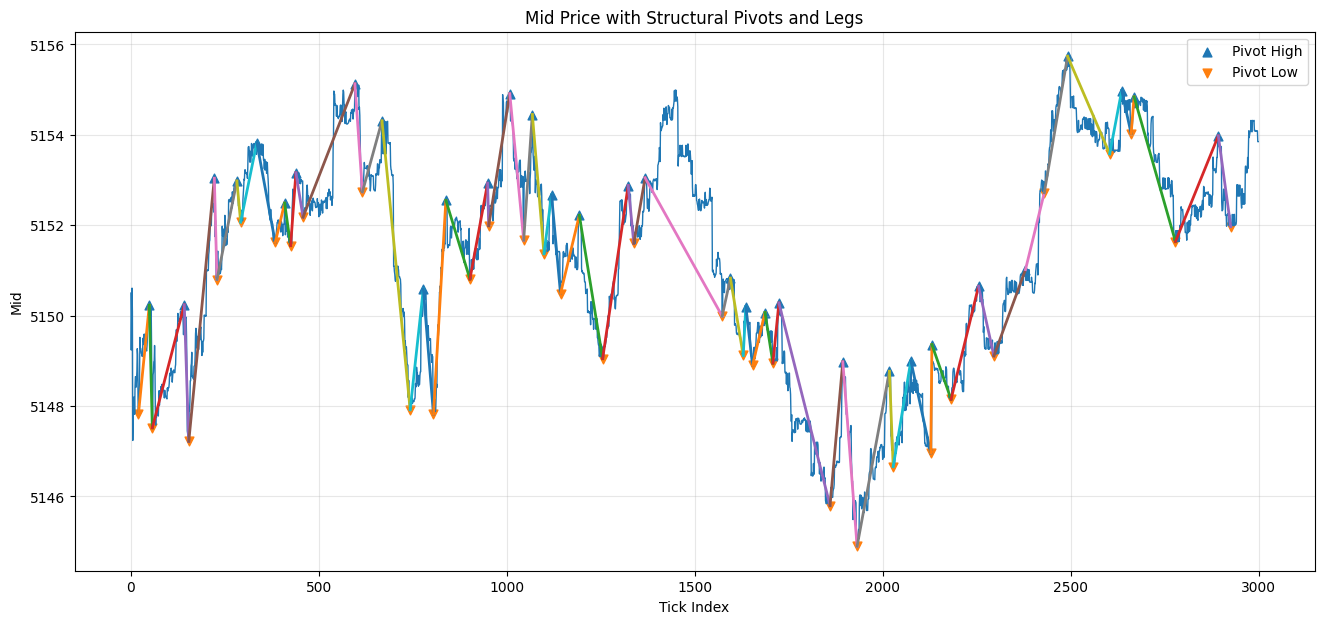

In [45]:
import matplotlib.pyplot as plt

PlotStart = 0
PlotEnd = 3000   # first slice; we can move later

DfPlot = Df.iloc[PlotStart:PlotEnd].copy()

PivotPlot = PivotDf[(PivotDf.index >= PlotStart) & (PivotDf.index <= PlotEnd)].copy()
LegPlot = Legs[
    (Legs["PivotIndex"] >= PlotStart) &
    (Legs["NextPivotIndex"] <= PlotEnd)
].copy()

plt.figure(figsize=(16, 7))
plt.plot(DfPlot.index, DfPlot["mid"], linewidth=1)

# Plot pivots
Highs = PivotPlot[PivotPlot["Type"] == "H"]
Lows = PivotPlot[PivotPlot["Type"] == "L"]

plt.scatter(Highs.index, Highs["Price"], marker="^", s=40, label="Pivot High")
plt.scatter(Lows.index, Lows["Price"], marker="v", s=40, label="Pivot Low")

# Plot legs
for _, row in LegPlot.iterrows():
    x = [row["PivotIndex"], int(row["NextPivotIndex"])]
    y = [row["PivotPrice"], row["NextPivotPrice"]]
    plt.plot(x, y, linewidth=2)

plt.title("Mid Price with Structural Pivots and Legs")
plt.xlabel("Tick Index")
plt.ylabel("Mid")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()